# Exemplo Aula 1 - Regressao: Um exemplo de Aprendizado Supervisionado

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

In [3]:
# --- 1. Dataset ---

df_regression = pd.read_csv('dados_vlor_imovel.csv')

In [4]:
df_regression

,n_comodos,valor
0,4,300444.436532
1,5,341444.141728
2,3,239363.651796
3,5,347650.489965
4,5,354441.578031
5,2,184640.469961
6,3,252849.292048
7,3,249306.956315
8,3,272686.785310
9,5,347905.089034


In [5]:
# Definir X e Y a partir do DataFrame
X = df_regression[['n_comodos']].values
Y = df_regression[['valor']].values

In [6]:
# --- 2. Divisão dos Dados em Conjuntos de Treino e Teste ---
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

print("--- Formato dos Dados de Treino e Teste ---")
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")
print("\n")

--- Formato dos Dados de Treino e Teste ---
X_train: (14, 1), Y_train: (14, 1)
X_test: (6, 1), Y_test: (6, 1)




In [7]:
# --- 3. Criação e Treinamento do Modelo de Regressão Linear ---
model = LinearRegression()
model.fit(X_train, Y_train)

print("--- Modelo Treinado com Sucesso! ---")


--- Modelo Treinado com Sucesso! ---


In [8]:
# --- 4. Realização de Previsões ---
Y_train_pred = model.predict(X_train)
Y_test_pred = model.predict(X_test)


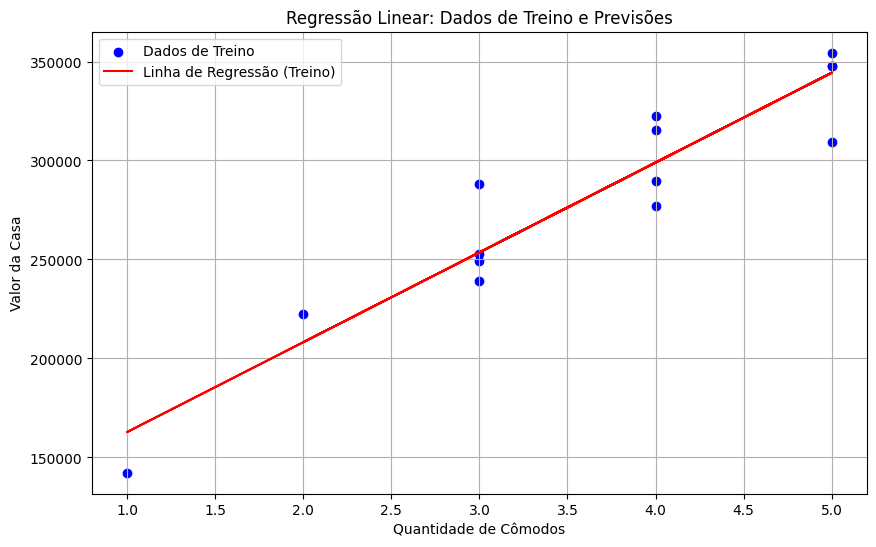

In [9]:
# --- 5. Plotagem: Previsão do Treino e Seus Pontos de Dados ---
plt.figure(figsize=(10, 6))
plt.scatter(X_train, Y_train, color='blue', label='Dados de Treino')
plt.plot(X_train, Y_train_pred, color='red', label='Linha de Regressão (Treino)')
plt.title('Regressão Linear: Dados de Treino e Previsões')
plt.xlabel('Quantidade de Cômodos')
plt.ylabel('Valor da Casa')
plt.legend()
plt.grid(True)
plt.show()


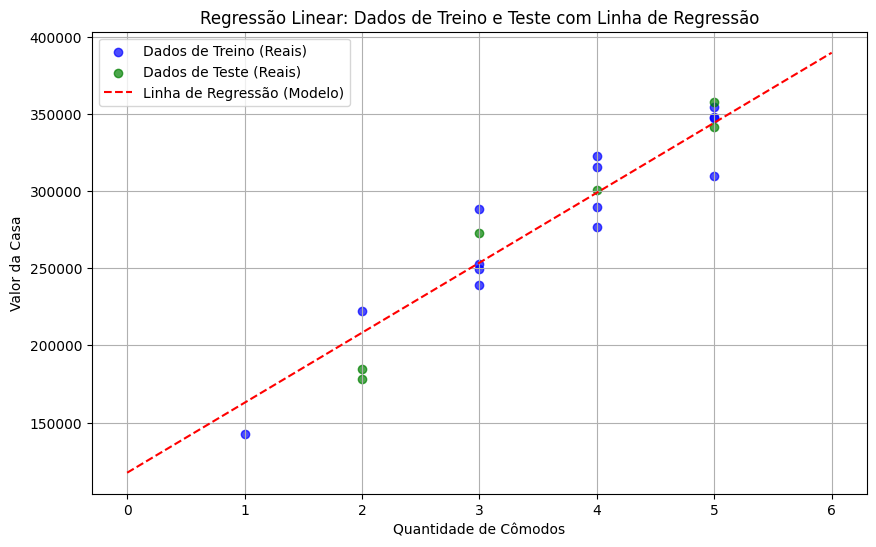

In [10]:
# --- 6. Plotagem: Previsão de Treino e Teste com Pontos de Dados em Diferentes Cores ---
plt.figure(figsize=(10, 6))
# Plotar os pontos de treino
plt.scatter(X_train, Y_train, color='blue', label='Dados de Treino (Reais)', alpha=0.7)
# Plotar os pontos de teste
plt.scatter(X_test, Y_test, color='green', label='Dados de Teste (Reais)', alpha=0.7)

# Plotar a linha de regressão (ajustada aos dados de treino)
# Para uma visualização clara da linha, geramos pontos no intervalo de X
X_range = np.linspace(X.min() - 1, X.max() + 1, 100).reshape(-1, 1)
Y_range_pred = model.predict(X_range)
plt.plot(X_range, Y_range_pred, color='red', linestyle='--', label='Linha de Regressão (Modelo)')

plt.title('Regressão Linear: Dados de Treino e Teste com Linha de Regressão')
plt.xlabel('Quantidade de Cômodos')
plt.ylabel('Valor da Casa')
plt.legend()
plt.grid(True)
plt.show()

# Aula 1 - Criando Gráfico de Viés e Variancia (Elemento para Slide)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas

# --- 1. Criar um Dataset Sintético com Relação Linear para ilustrar Viés/Variância ---
np.random.seed(42) # Usar a mesma seed da célula anterior para reprodutibilidade

# Carregar o DataFrame criado na célula anterior
# Isso garante que estamos usando "um df dos dados"
df_regression_bv = pd.read_csv('dados_vlor_imovel.csv')

# Definir X_raw e y_noisy a partir do DataFrame
# X_raw deve ser 2D para sklearn, y_noisy pode ser 1D (ravel() ao final)
X_raw = df_regression_bv[['n_comodos']].values
y_noisy = df_regression_bv['valor'].values

# A "verdadeira" função subjacente (linear, sem ruído)
# Usamos a mesma lógica do primeiro notebook para consistência,
# mas agora os dados X e Y vêm do df_regression_bv
true_fn = lambda x: 50000 * x + 100000

# Dividir em conjuntos de treino e teste
X_train_bv, X_test_bv, y_train_bv, y_test_bv = train_test_split(X_raw, y_noisy, test_size=0.3, random_state=42)

# --- 2. Treinar Modelos com Diferentes Complexidades ---

# Modelo de Alto Viés (Underfitting) - Modelo Constante (prevê a média)
# Este modelo é muito simples e não captura a tendência linear dos dados.
class ConstantPredictor:
    def fit(self, X, y):
        self.mean_val = np.mean(y)
    def predict(self, X):
        return np.full(X.shape[0], self.mean_val)

model_constant = ConstantPredictor()
model_constant.fit(X_train_bv, y_train_bv)

# Modelo de Bom Equilíbrio - Regressão Linear Simples
# Para uma relação linear subjacente, este é o modelo ideal.
model_linear = LinearRegression()
model_linear.fit(X_train_bv, y_train_bv)

# Modelo de Alta Variância (Overfitting) - Regressão Polinomial de Alto Grau
# Este modelo tentará se ajustar ao ruído nos dados de treino.
# Limitamos o grau para não exceder o número de amostras de treino - 1
degree_overfit = min(len(X_train_bv) - 1, 10) # Escolha um grau alto, e.g., 10
model_poly_high = make_pipeline(PolynomialFeatures(degree=degree_overfit), LinearRegression())
model_poly_high.fit(X_train_bv, y_train_bv)


# --- 3. Plotar os Resultados para Explicar Viés e Variância ---

plt.figure(figsize=(15, 8))
plt.scatter(X_train_bv, y_train_bv, color='blue', s=50, label='Dados de Treino', alpha=0.7)
plt.scatter(X_test_bv, y_test_bv, color='green', s=50, label='Dados de Teste', alpha=0.7, marker='x')

# Para plotar as previsões e a verdadeira função suavemente
X_plot = np.linspace(X_raw.min() - 1, X_raw.max() + 1, 100).reshape(-1, 1)
plt.plot(X_plot, true_fn(X_plot), color='black', linestyle='--', label='Função Verdadeira', linewidth=2)

# Previsões dos modelos
y_pred_constant = model_constant.predict(X_plot)
plt.plot(X_plot, y_pred_constant, color='red', label='Modelo Constante (Alto Viés / Underfitting)', linewidth=2)

y_pred_linear = model_linear.predict(X_plot)
plt.plot(X_plot, y_pred_linear, color='orange', label='Modelo Linear (Bom Equilíbrio)', linewidth=2)

y_pred_poly_high = model_poly_high.predict(X_plot)
plt.plot(X_plot, y_pred_poly_high, color='purple', label=f'Modelo Polinomial Grau {degree_overfit} (Alta Variância / Overfitting)', linewidth=2)

plt.title('Trade-off entre Viés e Variância em Regressão (Exemplo de Preço de Casa)')
plt.xlabel('Quantidade de Cômodos')
plt.ylabel('Valor da Casa')
plt.legend()
plt.grid(True)
plt.ylim(y_noisy.min() - 20000, y_noisy.max() + 20000) # Ajustar limites y para melhor visualização
plt.show()

# Aula 1 - Classificacao: um exemplo de Aprendizado Supervisionado

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score # Importar para medir a acurácia
import matplotlib.pyplot as plt


In [ ]:
# --- 1. Dataset para Classificação ---

df_class=pd.read_csv('dados_compra_casa.csv')

print("--- Primeiras 5 linhas do Dataset de Classificação ---")
print(df_class.head())
print("\n")



In [ ]:
# --- 2. Pré-processamento: Codificação de Variáveis Categóricas ---
# Para o bairro, usaremos One-Hot Encoding (transformando 'Bairro_Ruim' em 0 ou 1)
# 'Bairro_Ruim' é uma nova feature numérica binária.
df_class = pd.get_dummies(df_class, columns=['Bairro'], drop_first=True, prefix='Bairro')

In [ ]:
# Para a variável target 'Comprar', usaremos Label Encoding
# 'Comprar_Encoded' é a variável dependente em formato numérico (0 ou 1).
le = LabelEncoder()
df_class['Comprar_Encoded'] = le.fit_transform(df_class['Comprar'])


In [ ]:
# --- 3. Separação dos Dados em Variáveis Independentes (X) e Dependente (Y) ---
X_class = df_class[['Valor_Casa', 'Num_Comodos', 'Bairro_Ruim']] # Features
Y_class = df_class['Comprar_Encoded'] # Target

In [ ]:
# --- 4. Divisão dos Dados em Conjuntos de Treino e Teste (Opcional para este exemplo, mas boa prática) ---
X_train_class, X_test_class, Y_train_class, Y_test_class = train_test_split(X_class, Y_class, test_size=0.3, random_state=42)

print("--- Formato dos Dados de Treino e Teste para Classificação ---")
print(f"X_train_class: {X_train_class.shape}, Y_train_class: {Y_train_class.shape}")
print(f"X_test_class: {X_test_class.shape}, Y_test_class: {Y_test_class.shape}")
print("\n")

In [ ]:
# --- 5. Criação e Treinamento do Modelo de Árvore de Decisão ---
# max_depth=3 para uma árvore de três níveis como solicitado
model_dt = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt.fit(X_train_class, Y_train_class)

print("--- Modelo de Árvore de Decisão Treinado com Sucesso! ---")

In [ ]:
# --- 6. Avaliação do Modelo: Medição da Acurácia ---
# Previsões nos dados de treino
Y_train_pred_class = model_dt.predict(X_train_class)
# Acurácia nos dados de treino
accuracy_train = accuracy_score(Y_train_class, Y_train_pred_class)

# Previsões nos dados de teste
Y_test_pred_class = model_dt.predict(X_test_class)
# Acurácia nos dados de teste
accuracy_test = accuracy_score(Y_test_class, Y_test_pred_class)

print(f"Acurácia no conjunto de TREINO: {accuracy_train:.2f}")
print(f"Acurácia no conjunto de TESTE: {accuracy_test:.2f}")
print("\n")

In [ ]:
# --- 7. Plotagem da Árvore de Decisão ---
plt.figure(figsize=(20, 10)) # Tamanho maior para melhor visualização
plot_tree(model_dt,
          feature_names=X_class.columns.tolist(),
          class_names=le.classes_.tolist(), # Usar os nomes originais das classes
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Árvore de Decisão para Previsão de Compra de Casa (Max Depth = 3)')
plt.show()